# 02 — Training Replicas

For each window pair (A, B) this notebook:

1. Tunes hyperparameters **per window** using Optuna with TimeSeriesSplit, optimising PR-AUC.
2. Trains **R replicas** per window using stratified bootstrap sampling + different random seeds.
3. Evaluates on the common evaluation slice E_{A,B} (replica-averaged predictions, PR-AUC and ROC-AUC).
4. Identifies the **flagged set** F_{A,B} as the top K_FRAC fraction of eval instances ranked by max(p_hat_A, p_hat_B).

**Model types supported:** `'xgboost'` | `'logreg'`  ← set via `MODEL_TYPE` in the config cell.
MLP-PLR is trained in `02b_training_replicas.ipynb`.

**Input:** `data/processed/`, `data/windows/window_config.json`  
**Output per pair:** `data/models/{model_type}/pair_{pid:02d}/`
- `replicas_A/model_r{r}.joblib`, `replicas_B/model_r{r}.joblib` — R fitted models
- `replicas_A/seeds_r{r}.json`, `replicas_B/seeds_r{r}.json` — exact bootstrap/model seeds
- `hparams_A.json`, `hparams_B.json` — tuned hyperparameters
- `reference_scaler.joblib` — StandardScaler fit on window A's numeric features (used by notebook 04 for covariate drift, and by LR coefficient reprojection; NOT used internally by either model's training)
- `predictions.npz` — see schema below
- `coef_A.npy`, `coef_B.npy` *(LR only)* — replica coefficient tensors in each replica's own training-standardised basis, shape `(R, p)`
- `coef_A_ref.npy`, `coef_B_ref.npy` *(LR only)* — replica coefficients reprojected into the common pair-level reference basis (numeric per reference σ, binary in raw 0/1), shape `(R, p)`; consumed by notebook 04 for within-window coefficient instability
- `coef_A_full_ref.npy`, `coef_B_full_ref.npy` *(LR only)* — single deterministic full-window LR fit, reprojected into the same reference basis, shape `(p,)`; consumed by notebook 04 for the full-window A-vs-B coefficient comparison
- `full_model_A.joblib`, `full_model_B.joblib` *(LR only)* — fitted full-window LR pipelines (StandardScaler + LogisticRegression)

For XGBoost runs only:
- `replicas_A/training_log_r{r}.csv`, `replicas_B/training_log_r{r}.csv` — per-replica eval-metric curve

**`predictions.npz` schema (unchanged across model types):**
| Key | Shape | Meaning |
|---|---|---|
| `preds_A` | `(R, n_eval)` | per-replica positive-class probability, window A |
| `preds_B` | `(R, n_eval)` | per-replica positive-class probability, window B |
| `p_hat_A` | `(n_eval,)` | replica-averaged probability, window A |
| `p_hat_B` | `(n_eval,)` | replica-averaged probability, window B |
| `flagged_idx` | `(n_flagged,)` | local positions within `idx_eval` of the flagged set |
| `Y_eval` | `(n_eval,)` | true labels |
| `pr_auc_A` | scalar | average precision of `p_hat_A` |
| `pr_auc_B` | scalar | average precision of `p_hat_B` |
| `roc_auc_A` | scalar | ROC-AUC of `p_hat_A` |
| `roc_auc_B` | scalar | ROC-AUC of `p_hat_B` |
| `per_replica_pr_auc_A` | `(R,)` | PR-AUC of each individual replica, window A |
| `per_replica_pr_auc_B` | `(R,)` | PR-AUC of each individual replica, window B |

---

**Replica design:** Each replica differs by (1) a different random seed and (2) a stratified bootstrap sample.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%pip install optuna

In [3]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import average_precision_score, roc_auc_score
from xgboost import XGBClassifier
import optuna
from optuna.samplers import TPESampler

optuna.logging.set_verbosity(optuna.logging.WARNING)

WORKSPACE  = Path('/content/drive/MyDrive/Thesis/Shoppers_workspace')
PROC_DIR   = WORKSPACE / 'data' / 'processed'
WIN_DIR    = WORKSPACE / 'data' / 'windows'

# ── Fixed parameters (not tuned) ──────────────────────────────────────
XGB_FIXED = dict(
    tree_method  = 'hist',
    eval_metric  = 'aucpr',
    verbosity    = 0,
    n_jobs       = -1,
    objective    = 'binary:logistic',
)

import sklearn as _sklearn
_sk_ver = tuple(int(x) for x in _sklearn.__version__.split('.')[:2])
_lr_solver = 'newton-cholesky' if _sk_ver >= (1, 2) else 'lbfgs'

LR_FIXED = dict(
    solver   = _lr_solver,
    max_iter = 500,
)

# ── Tuning configuration ───────────────────────────────────────────────
N_TRIALS       = 30    # Optuna trials per window (XGBoost)
N_TRIALS_LR    = 30    # Optuna trials per window (Logistic Regression)
CV_N_SPLITS    = 3     # TimeSeriesSplit folds inside each window
ES_ROUNDS      = 50    # early stopping rounds (XGBoost only)
MAX_BOOST_RND  = 2000  # hard cap on n_estimators (XGBoost only)
VAL_TAIL_FRAC  = 0.15   # chronological window tail held out for XGBoost early stopping

print('Imports OK')
print(f'LR solver: {_lr_solver}  (sklearn {_sklearn.__version__})')

Imports OK
LR solver: newton-cholesky  (sklearn 1.6.1)


In [10]:
# ── Model-type configuration — change this between runs ───────────────
MODEL_TYPE = 'xgboost'   # 'xgboost' or 'logreg'

MODEL_DIR = WORKSPACE / 'data' / 'models' / MODEL_TYPE
MODEL_DIR.mkdir(parents=True, exist_ok=True)

print(f'MODEL_TYPE : {MODEL_TYPE}')
print(f'MODEL_DIR  : {MODEL_DIR}')

assert MODEL_TYPE in {'xgboost', 'logreg'}, (
    "MODEL_TYPE must be either 'xgboost' or 'logreg'. "
    f"Got: {MODEL_TYPE}"
)

MODEL_TYPE : xgboost
MODEL_DIR  : /content/drive/MyDrive/Thesis/Shoppers_workspace/data/models/xgboost


In [11]:
# ── Load processed data ────────────────────────────────────────────────
X_df = pd.read_parquet(PROC_DIR / 'X.parquet')
X    = X_df.values.astype(np.float32)
Y    = np.load(PROC_DIR / 'Y.npy').astype(np.int8)

with open(PROC_DIR / 'feature_names.json') as f:
    feat_names = json.load(f)
num_cols = feat_names['num']                              # 113 numeric feature names
num_col_idx = [X_df.columns.get_loc(c) for c in num_cols] # positions in X (for reference scaler)

with open(WIN_DIR / 'window_config.json') as f:
    config = json.load(f)

R       = config['parameters']['R']
K_FRAC  = config['parameters']['K_FRAC']
pairs   = config['pairs']

print(f'X: {X.shape}, Y: {Y.shape}')
print(f'R={R}, K_FRAC={K_FRAC}, {len(pairs)} window pairs')
print(f'Numeric feature count: {len(num_cols)}')

assert X.shape[0] == Y.shape[0], "X and Y have inconsistent lengths."
assert X.shape[1] == len(feat_names['all']), "Feature-name metadata does not match X."
assert set(feat_names['num']).issubset(set(X_df.columns)), "Some numeric feature names are missing from X."
assert len(pairs) > 0, "No rolling-window pairs found."
assert list(X_df.columns) == feat_names['all'], (
    "X.parquet column order does not match feature_names['all']. "
    "This would misalign saved attributions/coefficient names downstream."
)

X: (160057, 119), Y: (160057,)
R=8, K_FRAC=0.1, 2 window pairs
Numeric feature count: 113


In [12]:
# ═════════════════════════════════════════════════════════════════════════
# Helper functions
# ═════════════════════════════════════════════════════════════════════════
def stratified_bootstrap(idx: np.ndarray, Y: np.ndarray, seed: int) -> np.ndarray:
    """Stratified bootstrap: sample with replacement, preserving class ratio.

    Returns an array of row indices (into the global X/Y) with length equal to len(idx),
    containing the same number of positives and negatives as the input slice.
    """
    rng = np.random.default_rng(seed)
    pos = idx[Y[idx] == 1]
    neg = idx[Y[idx] == 0]
    boot_pos = rng.choice(pos, size=len(pos), replace=True)
    boot_neg = rng.choice(neg, size=len(neg), replace=True)
    out = np.concatenate([boot_pos, boot_neg])
    rng.shuffle(out)  # mix positives and negatives so the tail split is not all-positive
    return out


def _build_model(params: dict, seed: int, early_stopping_rounds: int = None) -> XGBClassifier:
    """Construct an XGBClassifier with fixed settings + tuned params + a given seed.

    early_stopping_rounds is passed to the constructor (required by XGBoost >= 2.0).
    """
    full = {**XGB_FIXED, **params, 'random_state': seed, 'n_estimators': MAX_BOOST_RND}
    if early_stopping_rounds is not None:
        full['early_stopping_rounds'] = early_stopping_rounds
    return XGBClassifier(**full)


def tune_hyperparameters_xgboost(window_idx: np.ndarray,
                                  X_all: np.ndarray,
                                  Y_all: np.ndarray,
                                  study_seed: int,
                                  n_trials: int = N_TRIALS) -> dict:
    """Optuna tuning of XGBoost hyperparameters on the given training window.

    Uses TimeSeriesSplit(CV_N_SPLITS) over the chronological order of window_idx.
    window_idx must be sorted by step (guaranteed by notebook 01's get_indices) so
    that each TSCV fold is a valid out-of-time validation set.
    The objective is mean PR-AUC across folds. Returns the best-trial parameter dict.
    """
    X_win = X_all[window_idx]   # preserves chronological step-sorted order
    Y_win = Y_all[window_idx]

    tscv = TimeSeriesSplit(n_splits=CV_N_SPLITS)

    def objective(trial: optuna.Trial) -> float:
        params = {
            'max_depth':        trial.suggest_int('max_depth', 4, 10),
            'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            'min_child_weight': trial.suggest_float('min_child_weight', 1.0, 20.0, log=True),
            'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
            'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
            'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
            'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
            'gamma':            trial.suggest_float('gamma', 1e-3, 10.0, log=True),
        }
        pr_aucs = []
        for fold, (tr, va) in enumerate(tscv.split(X_win)):
            model = _build_model(params, seed=study_seed + fold,
                                 early_stopping_rounds=ES_ROUNDS)
            model.fit(
                X_win[tr], Y_win[tr],
                eval_set=[(X_win[va], Y_win[va])],
                verbose=False,
            )
            p = model.predict_proba(X_win[va])[:, 1]
            pr_aucs.append(average_precision_score(Y_win[va], p))
        return float(np.mean(pr_aucs))

    sampler = TPESampler(seed=study_seed)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return dict(study.best_trial.params)


def tune_hyperparameters_logreg(window_idx: np.ndarray,
                                 X_all: np.ndarray,
                                 Y_all: np.ndarray,
                                 study_seed: int,
                                 n_trials: int = N_TRIALS_LR) -> dict:
    """Optuna tuning of LogisticRegression hyperparameters on the given training window.

    Uses TimeSeriesSplit(CV_N_SPLITS). window_idx must be sorted by step (guaranteed
    by notebook 01's get_indices). Optimises PR-AUC. Tunes C only (penalty fixed
    to 'l2' for speed). Returns best-trial parameter dict.
    """
    X_win = X_all[window_idx]   # preserves chronological step-sorted order
    Y_win = Y_all[window_idx]

    tscv = TimeSeriesSplit(n_splits=CV_N_SPLITS)

    def objective(trial: optuna.Trial) -> float:
        params = {
            'C':       trial.suggest_float('C', 1e-3, 10.0, log=True),
            'penalty': 'l2',
        }
        pr_aucs = []
        for fold, (tr, va) in enumerate(tscv.split(X_win)):
            pipe = Pipeline([
                ('scaler', StandardScaler()),
                ('model', LogisticRegression(**{**LR_FIXED, **params,
                                                'random_state': study_seed + fold}))
            ])
            pipe.fit(X_win[tr], Y_win[tr])
            p = pipe.predict_proba(X_win[va])[:, 1]
            pr_aucs.append(average_precision_score(Y_win[va], p))
        return float(np.mean(pr_aucs))

    sampler = TPESampler(seed=study_seed)
    study = optuna.create_study(direction='maximize', sampler=sampler)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)
    return dict(study.best_trial.params)


def train_replica_with_es(X_train: np.ndarray,
                           Y_train: np.ndarray,
                           X_val: np.ndarray,
                           Y_val: np.ndarray,
                           params: dict,
                           model_seed: int):
    """Train one XGBoost replica on a bootstrap sample with early stopping.

    X_val / Y_val must be the chronological tail of the original training window,
    extracted by the caller BEFORE bootstrapping (see main loop).  This guarantees
    early stopping monitors the most recent data in the window rather than a random
    tail of a shuffled bootstrap.  Returns (model, training_log_df).
    """
    model = _build_model(params, seed=model_seed, early_stopping_rounds=ES_ROUNDS)
    model.fit(
        X_train, Y_train,
        eval_set=[(X_val, Y_val)],
        verbose=False,
    )
    evals_result = model.evals_result()
    val_curve = evals_result.get('validation_0', {}).get('aucpr', [])
    training_log = pd.DataFrame({
        'iteration': np.arange(1, len(val_curve) + 1),
        'val_aucpr': val_curve,
    })
    return model, training_log


def train_replica_logreg(X_train: np.ndarray,
                          Y_train: np.ndarray,
                          params: dict,
                          model_seed: int) -> Pipeline:
    """Train one LR replica. Returns a fitted Pipeline(StandardScaler, LogisticRegression)."""
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(**{**LR_FIXED, **params, 'random_state': model_seed}))
    ])
    pipe.fit(X_train, Y_train)
    return pipe


def lr_coef_to_reference_basis(pipe: Pipeline,
                               reference_scaler: StandardScaler,
                               num_col_idx: list[int]) -> np.ndarray:
    """
    Convert coefficients from a fitted LR pipeline's own standardized basis
    into a common pair-level reference basis.

    Training pipeline:
        z_j = (x_j - mu_train_j) / sigma_train_j

    LR coefficient beta_std_j is per training-standardized unit.

    Convert to raw units:
        beta_raw_j = beta_std_j / sigma_train_j

    Then express numeric features per reference-standardized unit:
        beta_ref_j = beta_raw_j * sigma_ref_j

    Binary features remain in raw 0/1 units.
    """
    scaler = pipe.named_steps['scaler']
    model  = pipe.named_steps['model']

    beta_std = model.coef_.ravel().astype(np.float64)

    train_scale = scaler.scale_.astype(np.float64)
    train_scale_safe = np.where(train_scale == 0.0, 1.0, train_scale)

    beta_raw = beta_std / train_scale_safe

    beta_ref = beta_raw.copy()
    ref_scale = reference_scaler.scale_.astype(np.float64)

    for pos_in_ref, j in enumerate(num_col_idx):
        beta_ref[j] = beta_raw[j] * ref_scale[pos_in_ref]

    return beta_ref.astype(np.float32)

def train_full_window_logreg(X_train: np.ndarray,
                             Y_train: np.ndarray,
                             params: dict,
                             model_seed: int) -> Pipeline:
    """
    Deterministic full-window LR fit for the transparent A-vs-B coefficient
    comparison. No bootstrap; uses the tuned hyperparameters for the window.
    """
    return train_replica_logreg(
        X_train=X_train,
        Y_train=Y_train,
        params=params,
        model_seed=model_seed,
    )


def predict_proba_pos(model: XGBClassifier, X_in: np.ndarray) -> np.ndarray:
    """Return probability of positive class (uses best iteration if early stopping triggered)."""
    return model.predict_proba(X_in)[:, 1]


def compute_flagged_topk(p_hat_A: np.ndarray,
                          p_hat_B: np.ndarray,
                          k_frac: float) -> np.ndarray:
    """Top-K% flagged set: the top k_frac fraction of eval instances ranked by
    max(p_hat_A, p_hat_B). Returns local indices (positions within the eval slice).
    """
    assert p_hat_A.shape == p_hat_B.shape
    n = len(p_hat_A)
    k = max(int(np.ceil(k_frac * n)), 1)
    score = np.maximum(p_hat_A, p_hat_B)
    topk_unsorted = np.argpartition(-score, k - 1)[:k]
    return np.sort(topk_unsorted)


print('Helpers defined.')

def assert_binary_slice(y, name):
    assert len(np.unique(y)) == 2, f"{name} contains only one class."

Helpers defined.


In [13]:
# ═════════════════════════════════════════════════════════════════════════
# Main training loop — one iteration per window pair
# ═════════════════════════════════════════════════════════════════════════

SEED_BASE = 42

# Full run-configuration fingerprint used for staleness detection.
# If any of these settings change, existing predictions are treated as stale.
CURRENT_RUN_PARAMS = {
    'model_type': MODEL_TYPE,
    'seed_base': SEED_BASE,

    # Window / selection settings from window_config.json
    'window_parameters': {
        'L': int(config['parameters']['L']),
        'S': int(config['parameters']['S']),
        'H': int(config['parameters']['H']),
        'R': int(R),
        'K_FRAC': float(K_FRAC),
    },

    # Shared tuning settings
    'cv_n_splits': int(CV_N_SPLITS),
}

if MODEL_TYPE == 'logreg':
    CURRENT_RUN_PARAMS['lr_reference_basis_schema'] = 'coef_ref_basis_v1'
    CURRENT_RUN_PARAMS['lr_full_window_reference_fit'] = True

if MODEL_TYPE == 'xgboost':
    CURRENT_RUN_PARAMS.update({
        'n_trials_xgboost': int(N_TRIALS),
        'es_rounds':        int(ES_ROUNDS),
        'max_boost_round':  int(MAX_BOOST_RND),
        'val_tail_frac':    float(VAL_TAIL_FRAC),
        'xgb_fixed':        XGB_FIXED,
    })
else:  # logreg
    CURRENT_RUN_PARAMS.update({
        'n_trials_logreg': int(N_TRIALS_LR),
        'lr_fixed':        LR_FIXED,
    })

performance_log = []

for p in pairs:
    pid              = p['pair_id']
    pair_dir         = MODEL_DIR / f'pair_{pid:02d}'
    pred_file        = pair_dir / 'predictions.npz'
    run_params_file  = pair_dir / 'run_params.json'

     # ── Skip-if-done: validate full run configuration against saved run_params ──
    # Checking only for predictions.npz existence is insufficient: if tuning,
    # model, window, or selection settings change, existing predictions are stale.
    if pred_file.exists() and run_params_file.exists():
        with open(run_params_file) as f:
            saved = json.load(f)
        params_match = (saved == CURRENT_RUN_PARAMS)

        required_lr_files = [
            pair_dir / 'coef_A_ref.npy',
            pair_dir / 'coef_B_ref.npy',
            pair_dir / 'coef_A_full_ref.npy',
            pair_dir / 'coef_B_full_ref.npy',
            pair_dir / 'full_model_A.joblib',
            pair_dir / 'full_model_B.joblib',
        ]
        if MODEL_TYPE == 'logreg' and not all(p.exists() for p in required_lr_files):
            print(f'Pair {pid:02d}: LR coefficient artefacts missing — re-running.')
        else:
            if params_match:
                data = np.load(pred_file)
                if all(k in data.files for k in ('roc_auc_A', 'roc_auc_B')):
                    print(f'Pair {pid:02d}: already done, skipping.')
                    performance_log.append({
                        'pair_id':   pid,
                        'pr_auc_A':  float(data['pr_auc_A']),
                        'pr_auc_B':  float(data['pr_auc_B']),
                        'roc_auc_A': float(data['roc_auc_A']),
                        'roc_auc_B': float(data['roc_auc_B']),
                        'n_flagged': int(data['flagged_idx'].shape[0]),
                    })
                    continue
                else:
                    print(f'Pair {pid:02d}: stale predictions.npz (missing roc_auc keys) — re-running.')
            else:
                changed_keys = [
                    key for key in CURRENT_RUN_PARAMS
                    if saved.get(key) != CURRENT_RUN_PARAMS[key]
                ]
                print(f'Pair {pid:02d}: run_params changed in {changed_keys} — re-running.')
    
    elif pred_file.exists():
        print(f'Pair {pid:02d}: run_params.json missing — re-running.')

    print(f'\n── [{MODEL_TYPE}] Pair {pid:02d}: A_end={p["step_label_A"]}  B_end={p["step_label_B"]}  '
          f'eval={p["eval_start_label"]}→{p["eval_end_label"]}  '
          f'|A|={p["n_train_A"]:,} |B|={p["n_train_B"]:,} |eval|={p["n_eval"]:,} ──')

    idx_A    = np.array(p['idx_A'],    dtype=np.int64)
    idx_B    = np.array(p['idx_B'],    dtype=np.int64)
    idx_eval = np.array(p['idx_eval'], dtype=np.int64)

    # Safety check: no leakage across windows/eval
    assert len(set(idx_A.tolist())    & set(idx_eval.tolist())) == 0, 'idx_A and idx_eval overlap!'
    assert len(set(idx_B.tolist())    & set(idx_eval.tolist())) == 0, 'idx_B and idx_eval overlap!'

    X_eval = X[idx_eval]
    Y_eval = Y[idx_eval]

    assert_binary_slice(Y[idx_A], f"pair {pid:02d} window A")
    assert_binary_slice(Y[idx_B], f"pair {pid:02d} window B")
    assert_binary_slice(Y_eval, f"pair {pid:02d} eval slice")

    pair_dir.mkdir(parents=True, exist_ok=True)
    dir_A = pair_dir / 'replicas_A'
    dir_B = pair_dir / 'replicas_B'
    dir_A.mkdir(exist_ok=True)
    dir_B.mkdir(exist_ok=True)

    # ── Reference scaler (both model types; used by notebook 04 for covariate drift) ──
    # Fit on window A's numeric columns only; binary features are passed through unchanged.
    ref_scaler = StandardScaler()
    ref_scaler.fit(X[idx_A][:, num_col_idx])
    joblib.dump(ref_scaler, pair_dir / 'reference_scaler.joblib')

    # ── Tune hyperparameters per window ──
    print('  Tuning window A ...')
    if MODEL_TYPE == 'xgboost':
        hparams_A = tune_hyperparameters_xgboost(idx_A, X, Y, study_seed=SEED_BASE + pid * 10 + 1)
    else:  # logreg
        hparams_A = tune_hyperparameters_logreg(idx_A, X, Y, study_seed=SEED_BASE + pid * 10 + 1)
    with open(pair_dir / 'hparams_A.json', 'w') as f:
        json.dump(hparams_A, f, indent=2)
    print(f'    best A params: {hparams_A}')

    print('  Tuning window B ...')
    if MODEL_TYPE == 'xgboost':
        hparams_B = tune_hyperparameters_xgboost(idx_B, X, Y, study_seed=SEED_BASE + pid * 10 + 2)
    else:  # logreg
        hparams_B = tune_hyperparameters_logreg(idx_B, X, Y, study_seed=SEED_BASE + pid * 10 + 2)
    with open(pair_dir / 'hparams_B.json', 'w') as f:
        json.dump(hparams_B, f, indent=2)
    print(f'    best B params: {hparams_B}')

    # ── Chronological ES validation split (XGBoost only; done before bootstrapping) ──
    # Holding out the last VAL_TAIL_FRAC of the step-sorted window as the ES validator
    # ensures early stopping monitors the most recent data rather than a random tail
    # of a shuffled bootstrap.  LR has no early stopping so its bootstrap uses all of idx.
    if MODEL_TYPE == 'xgboost':
        n_es_A     = max(int(np.ceil(len(idx_A) * VAL_TAIL_FRAC)), 1)
        idx_A_boot = idx_A[:-n_es_A]   # bootstrap source (all but chronological tail)
        X_va_A     = X[idx_A[-n_es_A:]]
        Y_va_A     = Y[idx_A[-n_es_A:]]
        n_es_B     = max(int(np.ceil(len(idx_B) * VAL_TAIL_FRAC)), 1)
        idx_B_boot = idx_B[:-n_es_B]
        X_va_B     = X[idx_B[-n_es_B:]]
        Y_va_B     = Y[idx_B[-n_es_B:]]

        assert_binary_slice(Y_va_A, f"pair {pid:02d} window A early-stopping tail")
        assert_binary_slice(Y_va_B, f"pair {pid:02d} window B early-stopping tail")
        assert_binary_slice(Y[idx_A_boot], f"pair {pid:02d} window A bootstrap source")
        assert_binary_slice(Y[idx_B_boot], f"pair {pid:02d} window B bootstrap source")
    else:
        idx_A_boot = idx_A   # logreg: bootstrap from the full window
        idx_B_boot = idx_B

    # ── Train R replicas for window A ──
    preds_A = np.zeros((R, len(idx_eval)), dtype=np.float32)
    per_rep_pr_auc_A = np.zeros(R, dtype=np.float32)
    if MODEL_TYPE == 'logreg':
        coef_A = np.zeros((R, X.shape[1]), dtype=np.float32)
        coef_A_ref = np.zeros((R, X.shape[1]), dtype=np.float32)

    for r in range(R):
        boot_seed  = SEED_BASE + pid * 10_000 + r * 2          # A-bootstrap seeds are even
        model_seed = SEED_BASE + pid * 10_000 + r * 2 + 1      # A-model seeds are odd
        boot_idx   = stratified_bootstrap(idx_A_boot, Y, seed=boot_seed)
        X_tr = X[boot_idx]
        Y_tr = Y[boot_idx]

        if MODEL_TYPE == 'xgboost':
            model, training_log = train_replica_with_es(X_tr, Y_tr, X_va_A, Y_va_A, hparams_A, model_seed)
            preds_A[r] = predict_proba_pos(model, X_eval)
            joblib.dump(model, dir_A / f'model_r{r}.joblib', compress=3)
            training_log.to_csv(dir_A / f'training_log_r{r}.csv', index=False)
        else:  # logreg
            pipeline = train_replica_logreg(X_tr, Y_tr, hparams_A, model_seed)
            preds_A[r] = pipeline.predict_proba(X_eval)[:, 1]
            coef_A[r] = pipeline.named_steps['model'].coef_.ravel()
            coef_A_ref[r] = lr_coef_to_reference_basis(
                pipe=pipeline,
                reference_scaler=ref_scaler,
                num_col_idx=num_col_idx,
            )
            joblib.dump(pipeline, dir_A / f'model_r{r}.joblib', compress=3)

        per_rep_pr_auc_A[r] = average_precision_score(Y_eval, preds_A[r])
        with open(dir_A / f'seeds_r{r}.json', 'w') as f:
            json.dump({'bootstrap_seed': int(boot_seed),
                       'model_seed':     int(model_seed)}, f, indent=2)
        print(f'  A replica {r}: PR-AUC = {per_rep_pr_auc_A[r]:.4f}')


    # ── Train R replicas for window B ──
    preds_B = np.zeros((R, len(idx_eval)), dtype=np.float32)
    per_rep_pr_auc_B = np.zeros(R, dtype=np.float32)
    if MODEL_TYPE == 'logreg':
        coef_B = np.zeros((R, X.shape[1]), dtype=np.float32)
        coef_B_ref = np.zeros((R, X.shape[1]), dtype=np.float32)

    for r in range(R):
        boot_seed  = SEED_BASE + pid * 10_000 + 5_000 + r * 2      # B-bootstrap seeds (offset 5000)
        model_seed = SEED_BASE + pid * 10_000 + 5_000 + r * 2 + 1
        boot_idx   = stratified_bootstrap(idx_B_boot, Y, seed=boot_seed)
        X_tr = X[boot_idx]
        Y_tr = Y[boot_idx]

        if MODEL_TYPE == 'xgboost':
            model, training_log = train_replica_with_es(X_tr, Y_tr, X_va_B, Y_va_B, hparams_B, model_seed)
            preds_B[r] = predict_proba_pos(model, X_eval)
            joblib.dump(model, dir_B / f'model_r{r}.joblib', compress=3)
            training_log.to_csv(dir_B / f'training_log_r{r}.csv', index=False)
        else:  # logreg
            pipeline = train_replica_logreg(X_tr, Y_tr, hparams_B, model_seed)
            preds_B[r] = pipeline.predict_proba(X_eval)[:, 1]
            coef_B[r]  = pipeline.named_steps['model'].coef_.ravel()
            coef_B_ref[r] = lr_coef_to_reference_basis(
                pipe=pipeline,
                reference_scaler=ref_scaler,
                num_col_idx=num_col_idx,
            )
            joblib.dump(pipeline, dir_B / f'model_r{r}.joblib', compress=3)

        per_rep_pr_auc_B[r] = average_precision_score(Y_eval, preds_B[r])
        with open(dir_B / f'seeds_r{r}.json', 'w') as f:
            json.dump({'bootstrap_seed': int(boot_seed),
                       'model_seed':     int(model_seed)}, f, indent=2)
        print(f'  B replica {r}: PR-AUC = {per_rep_pr_auc_B[r]:.4f}')

    if MODEL_TYPE == 'logreg':
        np.save(pair_dir / 'coef_A.npy', coef_A)
        np.save(pair_dir / 'coef_A_ref.npy', coef_A_ref)
        print(f'  Saved coef_A.npy      shape={coef_A.shape}')
        print(f'  Saved coef_A_ref.npy  shape={coef_A_ref.shape}')

        np.save(pair_dir / 'coef_B.npy', coef_B)
        np.save(pair_dir / 'coef_B_ref.npy', coef_B_ref)
        print(f'  Saved coef_B.npy      shape={coef_B.shape}')
        print(f'  Saved coef_B_ref.npy  shape={coef_B_ref.shape}')

     # ── Full-window LR fit (no bootstrap, deterministic) ──
    # Used as a transparent reference for cross-window coefficient comparison.
    # Replica coefficients above are kept solely for within-window instability.
    if MODEL_TYPE == 'logreg':


        print('  Training full-window LR reference models ...')

        full_seed_A = SEED_BASE + pid * 10_000 + 999
        full_seed_B = SEED_BASE + pid * 10_000 + 5_999

        full_pipe_A = train_full_window_logreg(
            X_train=X[idx_A],
            Y_train=Y[idx_A],
            params=hparams_A,
            model_seed=full_seed_A,
        )
        full_pipe_B = train_full_window_logreg(
            X_train=X[idx_B],
            Y_train=Y[idx_B],
            params=hparams_B,
            model_seed=full_seed_B,
        )

        coef_A_full_ref = lr_coef_to_reference_basis(
            pipe=full_pipe_A,
            reference_scaler=ref_scaler,
            num_col_idx=num_col_idx,
        )
        coef_B_full_ref = lr_coef_to_reference_basis(
            pipe=full_pipe_B,
            reference_scaler=ref_scaler,
            num_col_idx=num_col_idx,
        )

        joblib.dump(full_pipe_A, pair_dir / 'full_model_A.joblib', compress=3)
        joblib.dump(full_pipe_B, pair_dir / 'full_model_B.joblib', compress=3)

        np.save(pair_dir / 'coef_A_full_ref.npy', coef_A_full_ref)
        np.save(pair_dir / 'coef_B_full_ref.npy', coef_B_full_ref)

        print(f'  Saved full_model_A/B.joblib')
        print(f'  Saved coef_A_full_ref.npy shape={coef_A_full_ref.shape}')
        print(f'  Saved coef_B_full_ref.npy shape={coef_B_full_ref.shape}')


    # ── Replica-averaged predictions and flagged set ──
    p_hat_A = preds_A.mean(axis=0)
    p_hat_B = preds_B.mean(axis=0)
    flagged_local_idx = compute_flagged_topk(p_hat_A, p_hat_B, K_FRAC)

    pr_auc_A  = average_precision_score(Y_eval, p_hat_A)
    pr_auc_B  = average_precision_score(Y_eval, p_hat_B)
    roc_auc_A = roc_auc_score(Y_eval, p_hat_A)
    roc_auc_B = roc_auc_score(Y_eval, p_hat_B)

    print(f'  Averaged: PR-AUC A = {pr_auc_A:.4f}, PR-AUC B = {pr_auc_B:.4f}')
    print(f'            ROC-AUC A = {roc_auc_A:.4f}, ROC-AUC B = {roc_auc_B:.4f}')
    print(f'  Flagged (top {K_FRAC:.0%}): {flagged_local_idx.shape[0]:,} / {len(idx_eval):,}')

    # ── Save predictions NPZ ──
    np.savez_compressed(
        pred_file,
        preds_A              = preds_A,
        preds_B              = preds_B,
        p_hat_A              = p_hat_A,
        p_hat_B              = p_hat_B,
        flagged_idx          = flagged_local_idx,
        Y_eval               = Y_eval,
        pr_auc_A             = np.float32(pr_auc_A),
        pr_auc_B             = np.float32(pr_auc_B),
        roc_auc_A            = np.float32(roc_auc_A),
        roc_auc_B            = np.float32(roc_auc_B),
        per_replica_pr_auc_A = per_rep_pr_auc_A,
        per_replica_pr_auc_B = per_rep_pr_auc_B,
    )

    # ── Save run params for staleness detection on future reruns ──
    with open(run_params_file, 'w') as f:
        json.dump(CURRENT_RUN_PARAMS, f, indent=2)

    performance_log.append({
        'pair_id':   pid,
        'pr_auc_A':  pr_auc_A,
        'pr_auc_B':  pr_auc_B,
        'roc_auc_A': roc_auc_A,
        'roc_auc_B': roc_auc_B,
        'n_flagged': flagged_local_idx.shape[0],
    })

print('\n✓ All window pairs processed.')

Pair 00: run_params changed in ['window_parameters', 'n_trials_xgboost'] — re-running.

── [xgboost] Pair 00: A_end=2013-03-25  B_end=2013-04-08  eval=2013-04-15→2013-04-22  |A|=66,292 |B|=100,342 |eval|=51,585 ──
  Tuning window A ...
    best A params: {'max_depth': 5, 'learning_rate': 0.014301108064764723, 'min_child_weight': 4.341991887022566, 'subsample': 0.6714817117922458, 'colsample_bytree': 0.6446322278177273, 'reg_alpha': 0.6778705909143024, 'reg_lambda': 0.0063385089447747485, 'gamma': 2.239321464043694}
  Tuning window B ...
    best B params: {'max_depth': 8, 'learning_rate': 0.023470603244879793, 'min_child_weight': 3.034975554230727, 'subsample': 0.6025554256995838, 'colsample_bytree': 0.6394246453301924, 'reg_alpha': 7.521493716815652, 'reg_lambda': 0.483624452528016, 'gamma': 0.01804859618197729}
  A replica 0: PR-AUC = 0.3962
  A replica 1: PR-AUC = 0.3842
  A replica 2: PR-AUC = 0.4399
  A replica 3: PR-AUC = 0.3904
  A replica 4: PR-AUC = 0.3917
  A replica 5: PR-AU

 pair_id  pr_auc_A  pr_auc_B  roc_auc_A  roc_auc_B  n_flagged
       0  0.422350  0.396823   0.549011   0.558011       5159
       1  0.421121  0.415499   0.561874   0.563032       4868

Mean PR-AUC  A: 0.4217   B: 0.4062
Mean ROC-AUC A: 0.5554   B: 0.5605


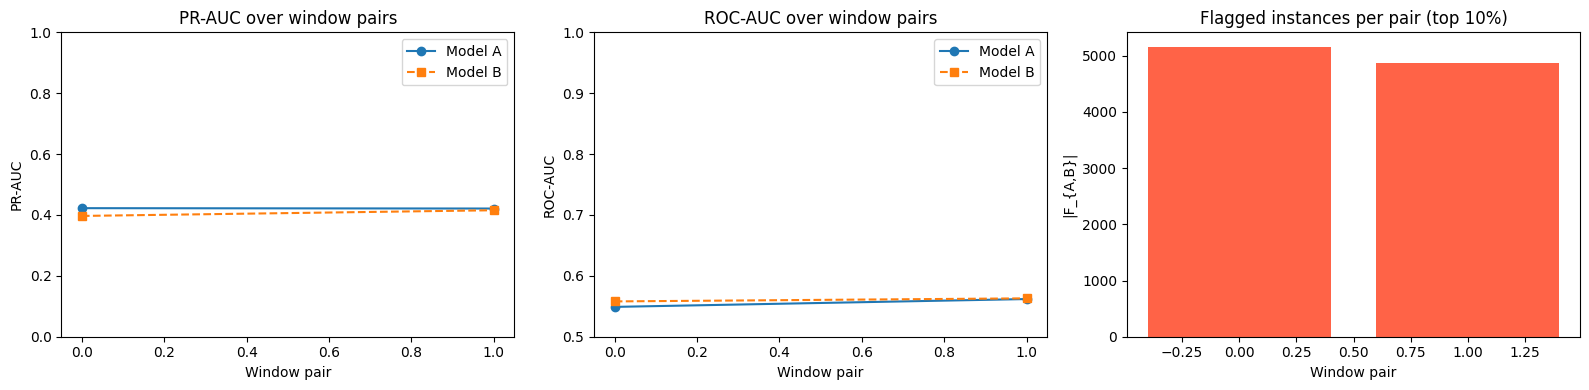

In [14]:
perf_df = pd.DataFrame(performance_log)
print(perf_df.to_string(index=False))
print(f'\nMean PR-AUC  A: {perf_df["pr_auc_A"].mean():.4f}   B: {perf_df["pr_auc_B"].mean():.4f}')
print(f'Mean ROC-AUC A: {perf_df["roc_auc_A"].mean():.4f}   B: {perf_df["roc_auc_B"].mean():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(perf_df['pair_id'], perf_df['pr_auc_A'], 'o-', label='Model A')
axes[0].plot(perf_df['pair_id'], perf_df['pr_auc_B'], 's--', label='Model B')
axes[0].set_title('PR-AUC over window pairs')
axes[0].set_xlabel('Window pair')
axes[0].set_ylabel('PR-AUC')
axes[0].legend()
axes[0].set_ylim(0, 1)

axes[1].plot(perf_df['pair_id'], perf_df['roc_auc_A'], 'o-', label='Model A')
axes[1].plot(perf_df['pair_id'], perf_df['roc_auc_B'], 's--', label='Model B')
axes[1].set_title('ROC-AUC over window pairs')
axes[1].set_xlabel('Window pair')
axes[1].set_ylabel('ROC-AUC')
axes[1].legend()
axes[1].set_ylim(0.5, 1)

axes[2].bar(perf_df['pair_id'], perf_df['n_flagged'], color='tomato')
axes[2].set_title(f'Flagged instances per pair (top {int(K_FRAC*100)}%)')
axes[2].set_xlabel('Window pair')
axes[2].set_ylabel('|F_{A,B}|')

plt.tight_layout()
plt.savefig(MODEL_DIR / 'performance_summary.png', dpi=120)
plt.show()

In [15]:
# Save performance log
perf_df.to_csv(MODEL_DIR / 'performance_log.csv', index=False)
print('Performance log saved.')

Performance log saved.
